# REFERENCES

- https://bayesiancomputationbook.com/markdown/chp_06.html
- https://www.pymc.io/projects/examples/en/latest/time_series/Forecasting_with_structural_timeseries.html

# SETUP

In [1]:
# Import main libs
from typing import List, Dict
import os
# Avoid PyTensor compiling error on eCryptfs
os.environ["NUMBA_CACHE_DIR"] = "/tmp/numba_cache"
os.environ["PYTENSOR_FLAGS"] = "base_compiledir=/tmp/pytensor_cache"
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from linearmodels import IV2SLS
import arviz as az
import preliz as pz
import pymc as pm
import xarray as xr
import pytensor.tensor as pt
import nutpie
az.style.use("preliz-doc")
# az.style.use("bmh")  # Bayesian Methods for Hackers style sheet

In [2]:
# Define constants
PYMC_MODELS_PATH: str = "pymc_models"
Path(PYMC_MODELS_PATH).mkdir(parents=True, exist_ok=True)
SEED: int = 5
DRAWS: int = 4_000
ROOT_PATH = Path.cwd()
print(f"Root path = {ROOT_PATH}")
N_CORES: int = os.cpu_count()
print(f"Number of cores = {N_CORES}")
N_CHAINS: int = int(N_CORES / 4)
print(f"Number of chains = {N_CHAINS}")

Root path = /home/gus-cunha/Projects/bayesian_causal_inference_study
Number of cores = 16
Number of chains = 4


# DATA

In [3]:
# Define variable names for time and target
T: str = "date_month"
T_idx: str = f"{T}_idx"
Y: str = "birth_in_thousands"

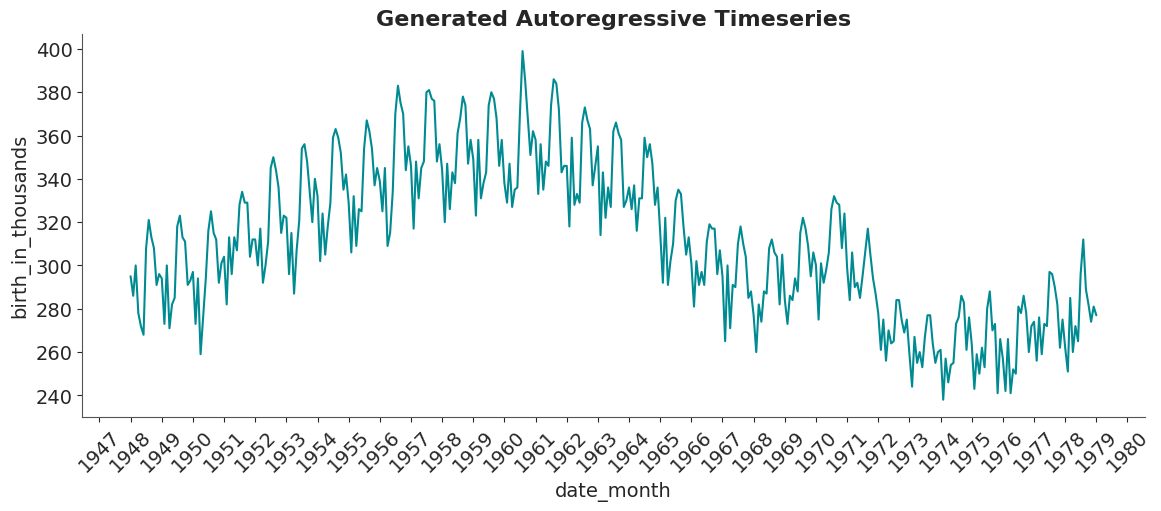

,date_month,birth_in_thousands,date_month_idx
0,1948-01-01,295.0,0
1,1948-02-01,286.0,1
2,1948-03-01,300.0,2
3,1948-04-01,278.0,3
4,1948-05-01,272.0,4
...,...,...,...
368,1978-09-01,289.0,368
369,1978-10-01,282.0,369
370,1978-11-01,274.0,370
371,1978-12-01,281.0,371


In [4]:
# Load data
df_ts: pd.DataFrame = pd.read_csv(
    filepath_or_buffer=os.path.join(ROOT_PATH, "data", "bayesian_time_series.csv")
)

# Convert datetime column into datetime format
df_ts: pd.DataFrame = df_ts.astype({
    T: "datetime64[s]"
})

# PyMC does not support datetime dtypes -> create a index col as well
df_ts[T_idx] = np.arange(len(df_ts[T]))

# Inspect data
ax = sns.lineplot(data=df_ts, x=T, y=Y)
ax.set_title("Generated Autoregressive Timeseries")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.tick_params(axis="x", rotation=45)
plt.show()

# Inspect data
df_ts

/home/gus-cunha/.pyenv/versions/3.12.3/envs/bayesian_causal_inference_study/lib/python3.12/site-packages/statsmodels/tsa/seasonal.py:360: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


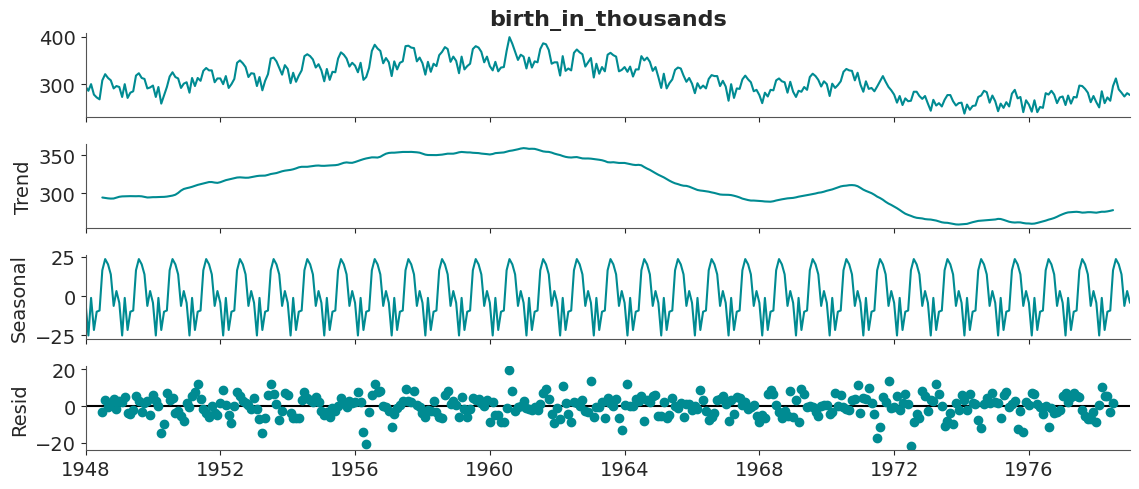

In [5]:
# Plot seasonal decomposition
sm.tsa.seasonal_decompose(
    x=df_ts.set_index(T)[Y],
    model='additive'
).plot()
plt.show()

In [6]:
# Define date to split between train and validation
dt_threshold: str = "2014-01-01"

# Split into train and validation
df_ts_train = df_ts[df_ts[T] < dt_threshold]
df_ts_val = df_ts[df_ts[T] >= dt_threshold]

# Inspect data
display(
    df_ts_train,
    df_ts_val
)

,date_month,birth_in_thousands,date_month_idx
0,1948-01-01,295.0,0
1,1948-02-01,286.0,1
2,1948-03-01,300.0,2
3,1948-04-01,278.0,3
4,1948-05-01,272.0,4
...,...,...,...
368,1978-09-01,289.0,368
369,1978-10-01,282.0,369
370,1978-11-01,274.0,370
371,1978-12-01,281.0,371


,date_month,birth_in_thousands,date_month_idx


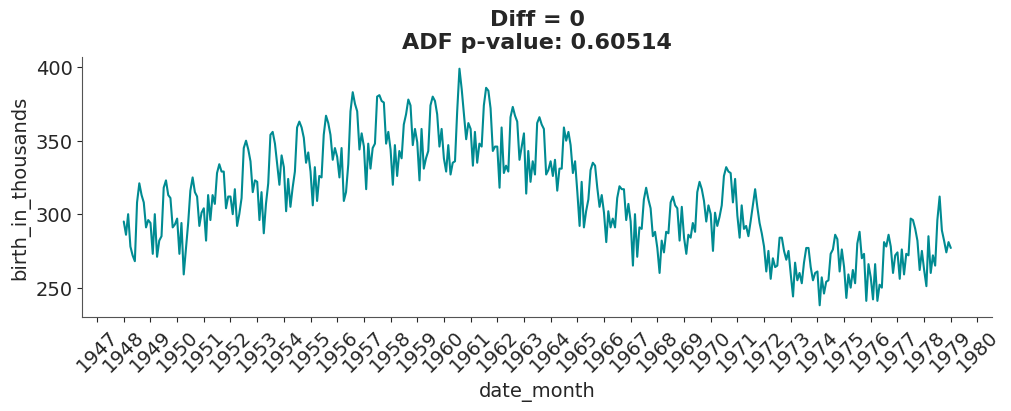

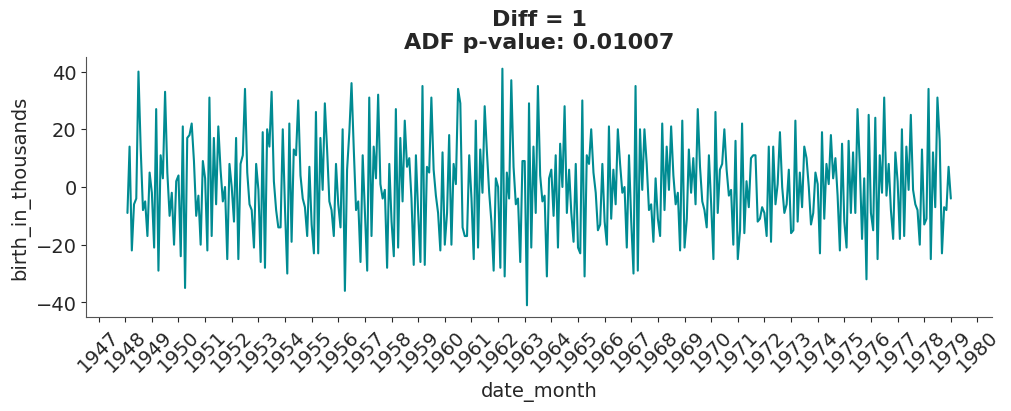

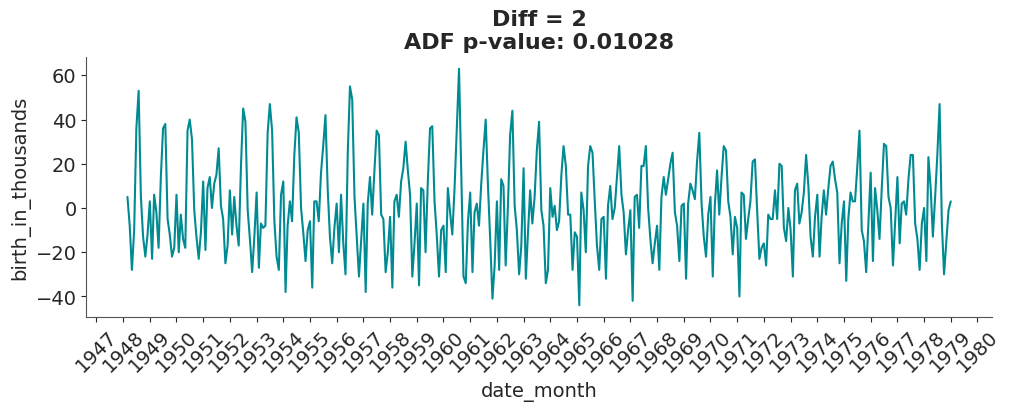

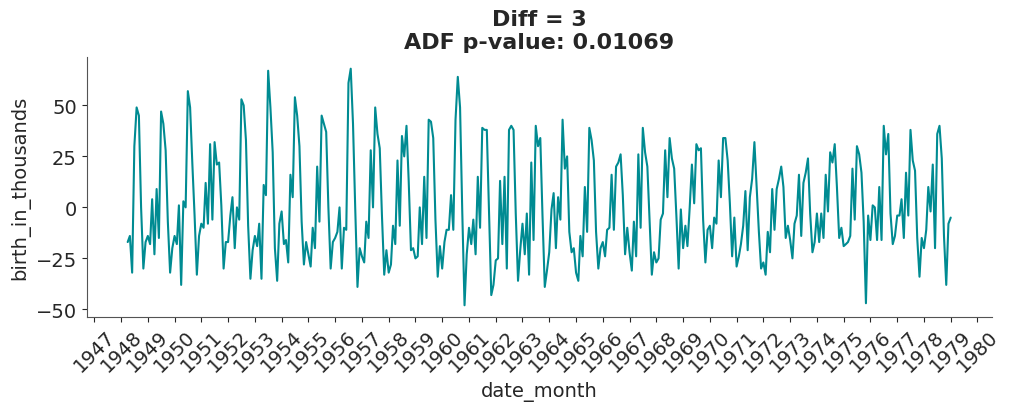

In [7]:
# Inspect how many times need to differentiate TS to get stationary
for diff_t in range(0, 3+1):
    # Make a copy of dataframe
    df_ts_diff: pd.DataFrame = df_ts.copy()
    # In case has to diff
    if diff_t > 0:
        # Diff time series
        df_ts_diff[Y] = df_ts_diff[Y].diff(periods=diff_t)

    # Perform ADF test
    result = adfuller(x=df_ts_diff[Y].dropna())

    # Define plot
    fig, ax = plt.subplots(figsize = (10, 4))
    sns.lineplot(data=df_ts_diff, x=T, y=Y, ax=ax)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis="x", rotation=45)
    # Set title
    ax.set_title(f"Diff = {diff_t}\nADF p-value: {result[1]:.5f}")
    plt.show()


In [8]:
# Get the stationary time series
df_ts_stationary: pd.DataFrame = df_ts.copy()
# df_ts_stationary[Y] = df_ts_stationary[Y].diff(periods=1)
# df_ts_stationary: pd.DataFrame =df_ts_stationary.dropna(axis="index", how="any", ignore_index=True)
# Inspect resulting time series
df_ts_stationary

,date_month,birth_in_thousands,date_month_idx
0,1948-01-01,295.0,0
1,1948-02-01,286.0,1
2,1948-03-01,300.0,2
3,1948-04-01,278.0,3
4,1948-05-01,272.0,4
...,...,...,...
368,1978-09-01,289.0,368
369,1978-10-01,282.0,369
370,1978-11-01,274.0,370
371,1978-12-01,281.0,371


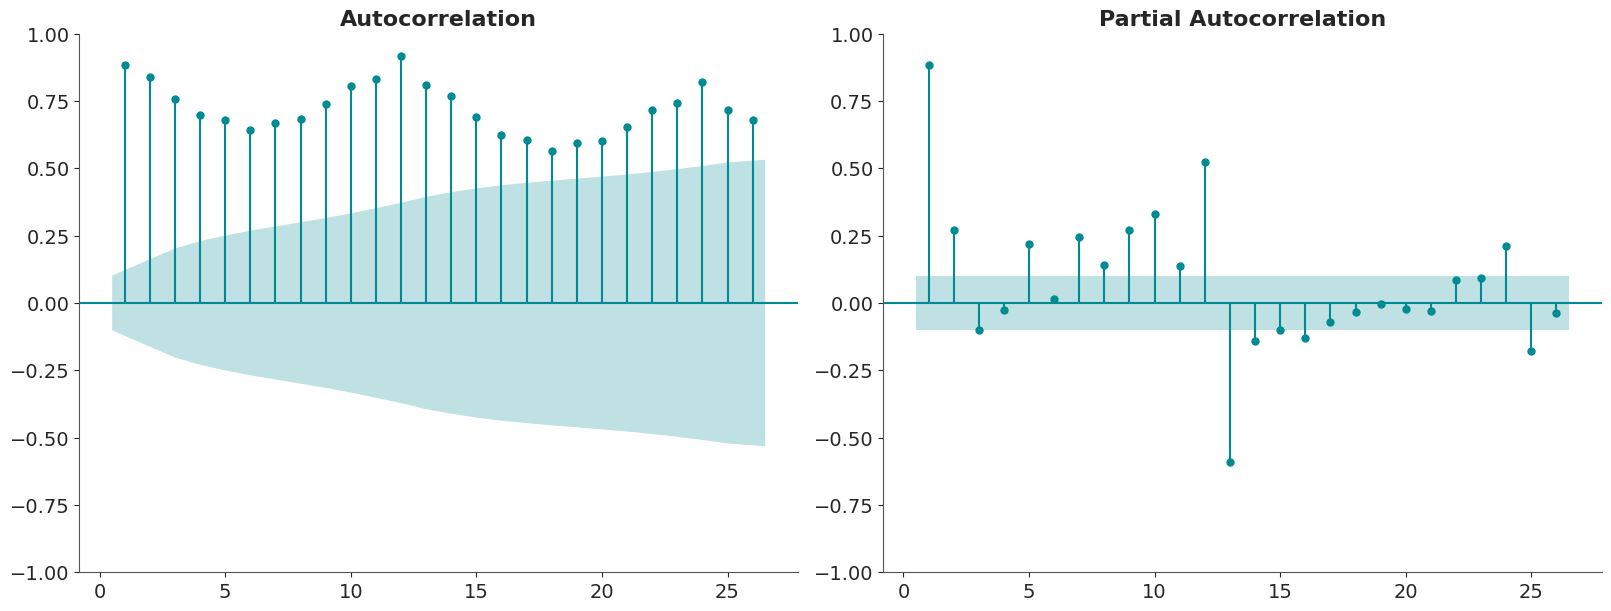

In [9]:
# Creating two subplots to show ACF and PACF plots
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 6))

# Creating and plotting the ACF charts starting from lag = 1
plot_acf(df_ts_stationary[Y], zero = False, alpha = 0.05, ax = ax1)

# Creating and plotting the ACF charts starting from lag = 1
plot_pacf(df_ts_stationary[Y], zero = False, alpha = 0.05, ax = ax2)
plt.show()

## FREQUENTIST

In [10]:
# Get a dataframe with arima format
df_freq_arima_train: pd.DataFrame = df_ts_train.copy()
# Set index to time stamp
df_freq_arima_train: pd.DataFrame = df_freq_arima_train.set_index(keys=T)
# Set index frequency to monthly frequency
df_freq_arima_train: pd.DataFrame = df_freq_arima_train.asfreq("MS")
df_freq_arima_train

,birth_in_thousands,date_month_idx
date_month,,
1948-01-01,295.0,0
1948-02-01,286.0,1
1948-03-01,300.0,2
1948-04-01,278.0,3
1948-05-01,272.0,4
...,...,...
1978-09-01,289.0,368
1978-10-01,282.0,369
1978-11-01,274.0,370


In [11]:
# Define params for ARIMA model
p: int = 2
d: int = 0
q: int = 0

# Instanciate ARIMA model
freq_arima = ARIMA(endog=df_freq_arima_train[Y], order = (p, d, q), seasonal_order=(0, 0, 0, 0))
# Fit the model
freq_arima_results = freq_arima.fit()
# Check the summary parameters
freq_arima_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:     birth_in_thousands   No. Observations:                  373
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1559.701
Date:                Fri, 24 Jul 2026   AIC                           3127.402
Time:                        16:04:58   BIC                           3143.088
Sample:                    01-01-1948   HQIC                          3133.631
                         - 01-01-1979                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        309.1320      9.812     31.506      0.000     289.901     328.363
ar.L1          0.6403      0.051     12.559      0.000       0.540       0.740
ar.L2          0.2746      0.052      5.313      0.000       0.173       0.376
sigma2       249.8010     20.847     11.983      0.000     208.942     290.661
===================================================================================
Ljung-Box (L1) (Q):                   0.32   Jarque-Bera (JB):                 4.29
Prob(Q):                              0.57   Prob(JB):                         0.12
Heteroskedasticity (H):               0.67   Skew:                             0.20
Prob(H) (two-sided):                  0.02   Kurtosis:                         2.65
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

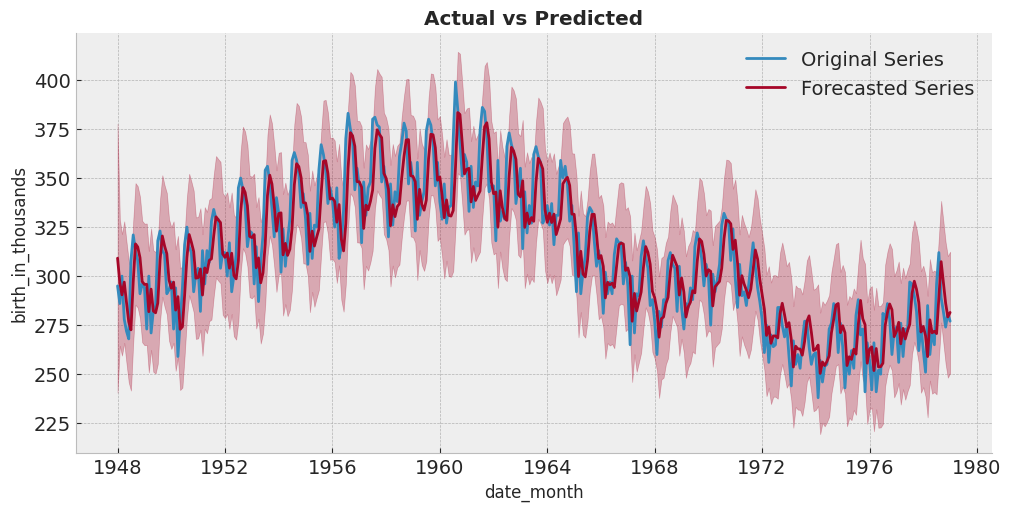

In [12]:
# Get predictions
df_freq_arima_forecast = freq_arima_results.get_prediction(
    start=df_ts[T].min(), end=df_ts[T].max()
).summary_frame(alpha=0.05).reset_index(
    drop=False, names=T
).iloc[d:]  # Avoid the first one that is noisy due to differentiation

with plt.style.context("bmh"):
    # Plotting the original time seris with forecast
    plt.figure(figsize = (10, 5))
    sns.lineplot(data=df_ts, x=T, y=Y, label="Original Series")
    forecast_plot=sns.lineplot(data=df_freq_arima_forecast, x=T, y="mean", label="Forecasted Series")
    plt.fill_between(
        x=df_freq_arima_forecast[T],
        y1=df_freq_arima_forecast["mean_ci_lower"],
        y2=df_freq_arima_forecast["mean_ci_upper"],
        color=forecast_plot.get_lines()[1].get_color(),
        alpha=0.3
    )
    plt.title('Actual vs Predicted')
    plt.legend()
    plt.show()

## BAYESIAN

,count,mean,min,25%,50%,75%,max,std,range
date_month,373,1963-07-02 01:32:40,1948-01-01 00:00:00,1955-10-01 00:00:00,1963-07-01 00:00:00,1971-04-01 00:00:00,1979-01-01 00:00:00,NaN,11323 days 00:00:00
birth_in_thousands,373.0,310.908847,238.0,284.0,310.0,336.0,399.0,35.250597,161.0
date_month_idx,373.0,186.0,0.0,93.0,186.0,279.0,372.0,107.820066,372.0


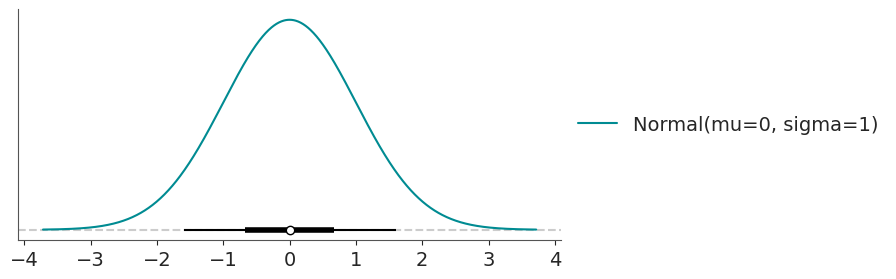

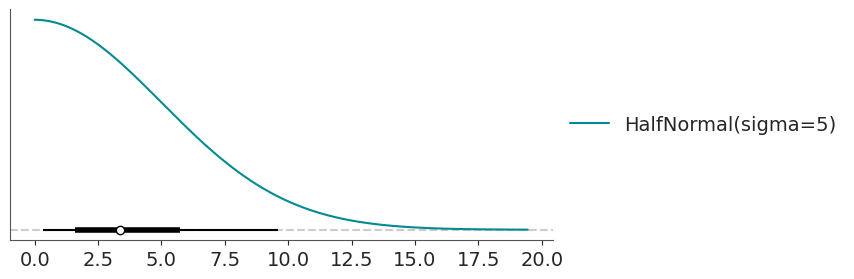

In [13]:
##########################
######### PRIORS #########
# Inspect variables
display(
    df_ts.describe().T.assign(**{
        "range": lambda df: df["max"] - df["min"]
    })
)

pz.Normal(mu=0, sigma=1).plot_pdf(pointinterval=True,figsize=(7, 3))
plt.show()
pz.HalfNormal(sigma=5).plot_pdf(pointinterval=True,figsize=(7, 3))
plt.show()

In [14]:
def prepare_ts_with_lag_and_fourier_seasonality(
    dataframe: pd.DataFrame,
    T_idx: str,
    Y: str,
    n_ar: int = 2,
    seasonality_period: int = 12
) -> Dict:
    # Make a copy of input dataset
    df: pd.DataFrame = dataframe[[T_idx, Y]].copy()

    # Define list for shift cols
    lag_shift_cols: List[str] = []
    # Iterate over defined AR components
    for ar_shift in range(1, n_ar+1):
        # Create a shift col
        shif_col_name: str = f"{Y}_shift_{ar_shift}"
        # Add to list of shifts
        lag_shift_cols.append(shif_col_name)
        df[shif_col_name] = df[Y].shift(ar_shift)

    # Define list for shift cols
    fourier_season_cols: List[str] = []
    # Create seasonality features
    # 2 * np.pi * time / period
    # sin col
    seasonality_col_name = f"{T_idx}_sin"
    df[seasonality_col_name] = np.sin(2 * np.pi * df[T_idx] / seasonality_period)
    fourier_season_cols.append(seasonality_col_name)
    # cos col
    seasonality_col_name = f"{T_idx}_cos"
    df[seasonality_col_name] = np.cos(2 * np.pi * df[T_idx] / seasonality_period)
    fourier_season_cols.append(seasonality_col_name)

    # Remove rows with NAs due to shift as PyMC doesn't accept them
    df = df.dropna(axis="index", how="any", ignore_index=True)

    return {
        "dataframe": df,
        "lag_shift_cols": lag_shift_cols,
        "fourier_season_cols": fourier_season_cols
    }

In [15]:
############################
######### BAYESIAN #########


# Define variable names for time and target
T: str = "date_month"
T_idx: str = f"{T}_idx"
Y: str = "birth_in_thousands"

# Prepare data
dict_ts: Dict = prepare_ts_with_lag_and_fourier_seasonality(
    dataframe=df_ts_train,
    T_idx=T_idx,
    Y=Y,
    n_ar=3,
    seasonality_period=12
)

# Get data and params
df_ts_bayes = dict_ts["dataframe"]
lag_shift_cols = dict_ts["lag_shift_cols"]
fourier_season_cols = dict_ts["fourier_season_cols"]

# Define coordinates
coords = {
    "time_idx": df_ts_bayes[T_idx],  # PyMC does not support datetime dtypes
    "lag_shift_cols": lag_shift_cols,
    "fourier_season_cols": fourier_season_cols
}

with pm.Model(coords=coords) as model_ts:
    ######### Sanity check #########
    for name, coord in coords.items():
        print(f"coord `{name}` has len = `{len(coord)}`")

    ##########################
    # Define data containter #
    Y_obs = pm.Data(
        name="Y_obs", value=df_ts_bayes[Y].values, dims="time_idx"
    )
    # Create shift columns
    Y_obs_lag_shifts = pm.Data(
        name="Y_obs_lag_shifts",
        value=df_ts_bayes[lag_shift_cols].values,
        dims=("time_idx", "lag_shift_cols")
    )
    # Create shift columns
    Y_obs_fourier_season = pm.Data(
        name="Y_obs_fourier_season",
        value=df_ts_bayes[fourier_season_cols].values,
        dims=("time_idx", "fourier_season_cols")
    )
    # Sanity check
    print(
        f"Y_obs.shape: {Y_obs.shape.eval()}",
        f"Y_obs_lag_shifts.shape: {Y_obs_lag_shifts.shape.eval()}",
        f"Y_obs_fourier_season.shape: {Y_obs_fourier_season.shape.eval()}",
    )


    ##########
    # Priors #
    α = pm.Normal("α", mu=5, sigma=5)
    β_lag_shifts = pm.Normal(name="β_lag_shifts", mu=0, sigma=1, dims="lag_shift_cols")
    β_fourier_season = pm.Normal(name="β_fourier_season", mu=0, sigma=1, dims="fourier_season_cols")        
    σ = pm.HalfNormal(name="σ", sigma=5)
    # Sanity check
    print(
        f"β_lag_shifts.shape: {β_lag_shifts.shape.eval()}",
        f"β_fourier_season.shape: {β_fourier_season.shape.eval()}",                
    )


    ##############
    # Likelihood #
    # math.dot to get shape (n_obs,) - not a element wise product
    μ = (
        α + 
        pm.math.dot(Y_obs_lag_shifts, β_lag_shifts) +
        pm.math.dot(Y_obs_fourier_season, β_fourier_season)                
    )
    y_pred = pm.Normal(name="y_pred", mu=μ, sigma=σ, observed=Y_obs)
    # Sanity check
    print(
        f"μ.shape: {μ.shape.eval()}",
    )


    #################
    # MCMC sampling #
    idata_ts = pm.sample(
        nuts_sampler="nutpie",
        target_accept=0.9,
        draws=DRAWS,
        tune=DRAWS,
        chains=N_CHAINS,
        cores=N_CHAINS,
        random_seed=SEED,
        progressbar=True,
        discard_tuned_samples=True,
        return_inferencedata=True,
    )
    pm.compute_log_likelihood(
        idata=idata_ts, extend_inferencedata=True
    )

# Save a checkpoint
idata_ts.to_netcdf(
    filepath=os.path.join(PYMC_MODELS_PATH, "model_ts.nc")
)

# Inspect idata
idata_ts

coord `time_idx` has len = `370`
coord `lag_shift_cols` has len = `3`
coord `fourier_season_cols` has len = `2`
Y_obs.shape: [370] Y_obs_lag_shifts.shape: [370   3] Y_obs_fourier_season.shape: [370   2]
β_lag_shifts.shape: [3] β_fourier_season.shape: [2]
μ.shape: [370]


NUTS[nutpie]: [α, β_lag_shifts, β_fourier_season, σ]


Output()

Output()

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:              (chain: 4, draw: 4000, lag_shift_cols: 3,
│                                 fourier_season_cols: 2)
│       Coordinates:
│         * chain                (chain) int64 32B 0 1 2 3
│         * draw                 (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
│         * lag_shift_cols       (lag_shift_cols) object 24B 'birth_in_thousands_shif...
│         * fourier_season_cols  (fourier_season_cols) object 16B 'date_month_idx_sin...
│       Data variables:
│           α                    (chain, draw) float64 128kB 10.65 12.37 ... 11.9 15.75
│           β_lag_shifts         (chain, draw, lag_shift_cols) float64 384kB 0.54 ......
│           β_fourier_season     (chain, draw, fourier_season_cols) float64 256kB 0.6...
│           σ                    (chain, draw) float64 128kB 14.76 14.13 ... 14.13 14.34
│       Attributes:
│           created_at:                 2026-07-24T19:05:10.811558+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              5.050434589385986
│           tuning_steps:               4000
├── Group: /sample_stats
│       Dimensions:                   (chain: 4, draw: 4000)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 32kB 0 1 2 3 ... 3996 3997 3998 3999
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 128kB 4 6 6 6 6 ... 5 6 2 5 5
│           maxdepth_reached          (chain, draw) bool 16kB False False ... False
│           step_size                 (chain, draw) float64 128kB 0.138 ... 0.1405
│           transformation_update_id  (chain, draw) int64 128kB 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 128kB 0.1497 ... 0.145
│           mean_tree_accept          (chain, draw) float64 128kB 0.9877 ... 0.7303
│           ...                        ...
│           fisher_distance           (chain, draw) float64 128kB 115.0 278.8 ... 266.3
│           transformation_index      (chain, draw) int64 128kB 3398 3398 ... 3398 3398
│           diverging                 (chain, draw) bool 16kB False False ... False
│           divergence_draw           (chain, draw) uint64 128kB 0 0 0 0 0 ... 0 0 0 0 0
│           divergence_message        (chain, draw) object 128kB None None ... None None
│           divergence_energy_error   (chain, draw) float64 128kB nan nan ... nan nan
│       Attributes:
│           created_at:                  2026-07-24T19:05:10.799383+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.1.0
│           creation_library_language:   Python
│           sample_dims:                 ['chain', 'draw']
│           inference_library:           nutpie
│           inference_library_version:   0.16.11
│           inference_library_settings:  {"sampler": "nuts", "adaptation": "diag", "s...
├── Group: /constant_data
│       Dimensions:               (time_idx: 370, lag_shift_cols: 3,
│                                  fourier_season_cols: 2)
│       Coordinates:
│         * time_idx              (time_idx) int64 3kB 3 4 5 6 7 ... 368 369 370 371 372
│         * lag_shift_cols        (lag_shift_cols) <U26 312B 'birth_in_thousands_shif...
│         * fourier_season_cols   (fourier_season_cols) <U18 144B 'date_month_idx_sin...
│       Data variables:
│           Y_obs                 (time_idx) float64 3kB 278.0 272.0 ... 281.0 277.0
│           Y_obs_lag_shifts      (time_idx, lag_shift_cols) float64 9kB 300.0 ... 282.0
│           Y_obs_fourier_season  (time_idx, fourier_season_cols) float64 6kB 1.0 ......
│       Attributes:
│        

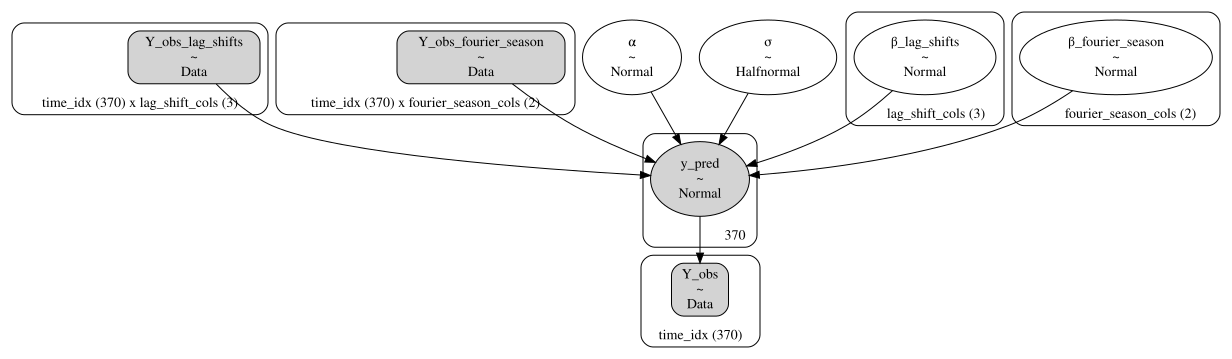

In [16]:
# plot graph
model_ts.to_graphviz()

In [17]:
# Inspect summary
# R hat
#   compute the variance between chains with the variance within chains
#   Ideally = 1, okay if < 1.01
# ESS (Effective Sample Size)
#   Less than the draws due to autocorrelation
#   At least 400 (100 ESS per chain) -> the higher the better
# MCSE - Monte Carlo Standard Error
#   Error introduced on MC posterior due to 
#   finite sampling and samples not being truely independent
#   It impact the precision of results
#   The pass criteria to check:
#       mcse_mean / sd (from the same table) below ~5–10%
#       If those all pass (R hat, ESS and MCSE), a U shape MCSE plot is fine as-is
#       the shape is just the normal signature of tail quantiles being harder to pin down.
summary = az.summary(
    data=idata_ts,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind='all', fmt='wide', ci_prob=0.95, ci_kind="hdi",
    round_to='auto', skipna=False
)

# Relative MCSE: how big is the sampling error compared to the posterior's own spread?
#   mcse_mean_pct = MCSE of the posterior mean, as a % of the posterior SD.
#       Rule of thumb: < 5–10% is fine; 
#       higher means you'd need more draws to trust the reported mean/HDI to that many significant digits.
#   mcse_sd_pct = same idea for the SD estimate.
summary["mcse_mean_pct"] = summary["mcse_mean"].astype(float) / summary["sd"].astype(float)
summary["mcse_sd_pct"]   = summary["mcse_sd"].astype(float)   / summary["sd"].astype(float)
summary: pd.DataFrame = summary.astype("float")
summary

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd,mcse_mean_pct,mcse_sd_pct
α,10.590,4.020,2.700,18.00,9315.0,9090.0,1.0,0.04200,0.03000,0.010448,0.007463
β_lag_shifts[birth_in_thousands_shift_1],0.567,0.049,0.470,0.66,4409.0,5112.0,1.0,0.00074,0.00054,0.015102,0.011020
β_lag_shifts[birth_in_thousands_shift_2],0.372,0.054,0.270,0.48,3875.0,4736.0,1.0,0.00086,0.00065,0.015926,0.012037
β_lag_shifts[birth_in_thousands_shift_3],0.026,0.049,-0.071,0.12,4292.0,5128.0,1.0,0.00075,0.00054,0.015306,0.011020
β_fourier_season[date_month_idx_sin],0.750,0.739,-0.690,2.20,16532.0,10494.0,1.0,0.00570,0.00400,0.007713,0.005413
β_fourier_season[date_month_idx_cos],-5.980,0.850,-7.700,-4.30,12057.0,11552.0,1.0,0.00770,0.00550,0.009059,0.006471
σ,14.123,0.544,13.000,15.00,18240.0,12638.0,1.0,0.00400,0.00290,0.007353,0.005331


In [18]:
# Inspect problematic params
problematic_params = summary[
    (
        summary.r_hat > 1.01
    ) | (
        summary.ess_bulk < N_CHAINS*100
    ) | (
        summary.ess_tail < N_CHAINS*100
    ) | (
        summary.mcse_mean_pct > 0.05
    )
]
problematic_params

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd,mcse_mean_pct,mcse_sd_pct


In [19]:
# Get posterior predictive
with model_ts:
    pm.sample_posterior_predictive(
        trace=idata_ts,
        random_seed=SEED, progressbar=True,
        return_inferencedata=True, extend_inferencedata=True
)

# Save a checkpoint
idata_ts.to_netcdf(
    filepath=os.path.join(PYMC_MODELS_PATH, "model_sc.nc")
)

Sampling: [y_pred]


Output()

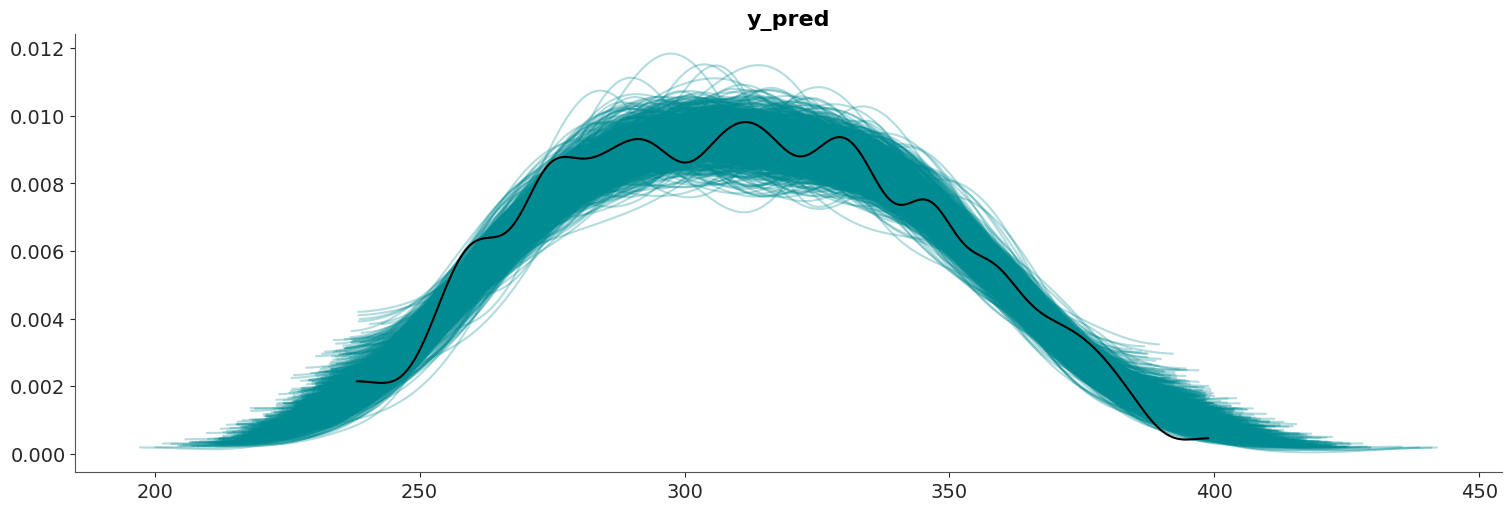

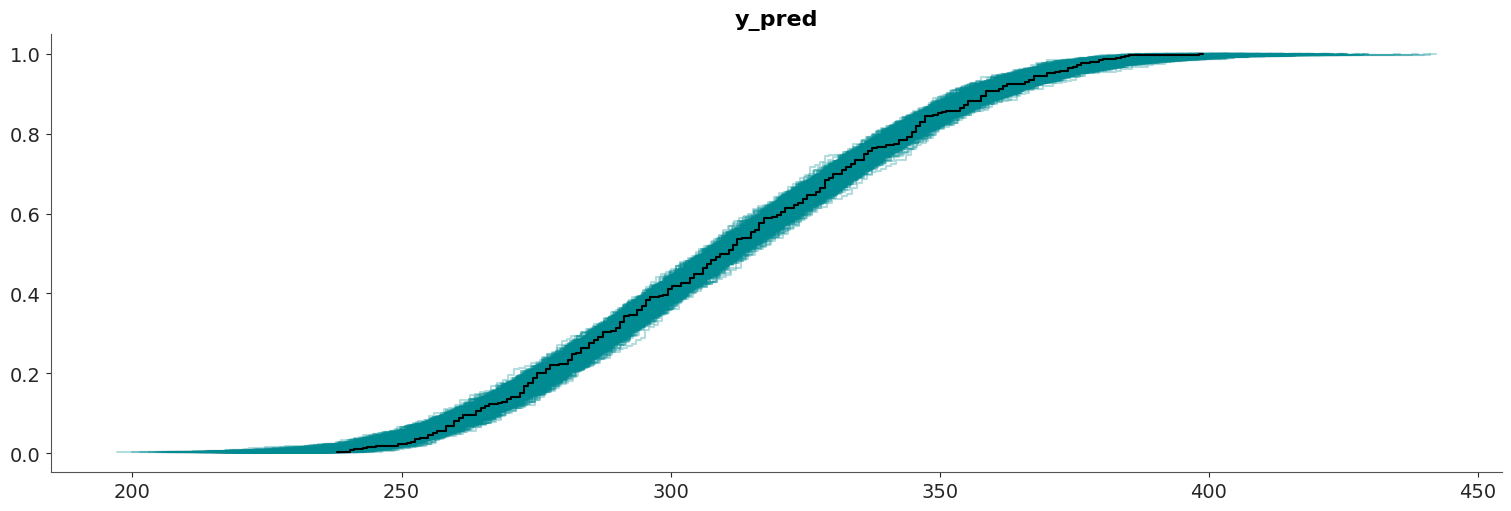

In [20]:
# Inspect posterior predictive
# Does the fitted combination reproduce the treated unit's pre-period trend?
az.plot_ppc_dist(
    dt=idata_ts, 
    var_names=None, filter_vars=None,
    group='posterior_predictive', coords=None, sample_dims=None,
    kind='kde', num_samples=1_000, stats=None,
    figure_kwargs={"figsize": (15, 5)},
)
plt.show()

# Inspect posterior predictive
# Does the fitted combination reproduce the treated unit's pre-period trend?
az.plot_ppc_dist(
    dt=idata_ts, 
    var_names=None, filter_vars=None,
    group='posterior_predictive', coords=None, sample_dims=None,
    kind='ecdf', num_samples=1_000, stats=None,
    figure_kwargs={"figsize": (15, 5)},
)
plt.show()

In [21]:
# Prepare data
dict_ts_pred: Dict = prepare_ts_with_lag_and_fourier_seasonality(
    dataframe=df_ts,
    T_idx=T_idx,
    Y=Y,
    n_ar=3,
    seasonality_period=12
)

# Get data and params
df_ts_bayes_pred = dict_ts_pred["dataframe"]

# Get predicitons
with model_ts:
    # Overwrite training container
    pm.set_data(
        new_data={
            "Y_obs": df_ts_bayes_pred[Y].values,  # Not used for pred, but required to set_data to keep shape
            "Y_obs_lag_shifts": df_ts_bayes_pred[coords["lag_shift_cols"]].values,
            "Y_obs_fourier_season": df_ts_bayes_pred[coords["fourier_season_cols"]].values

        },
        # pm.set_data's coords argument only needs entries for dims whose length changes
        # If coords was used on training is not defined here, it will be assumed to stay the same
        coords={
            "time_idx": df_ts_bayes_pred[T_idx].values
        },
    )
    # Get predictions
    pm.sample_posterior_predictive(
        trace=idata_ts,
        var_names=["y_pred"],
        predictions=True,  # store predictions in a separate predictions group.
        random_seed=SEED, progressbar=True,
        return_inferencedata=True, extend_inferencedata=True
    )

Sampling: [y_pred]


Output()

/tmp/ipykernel_158616/2673989766.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


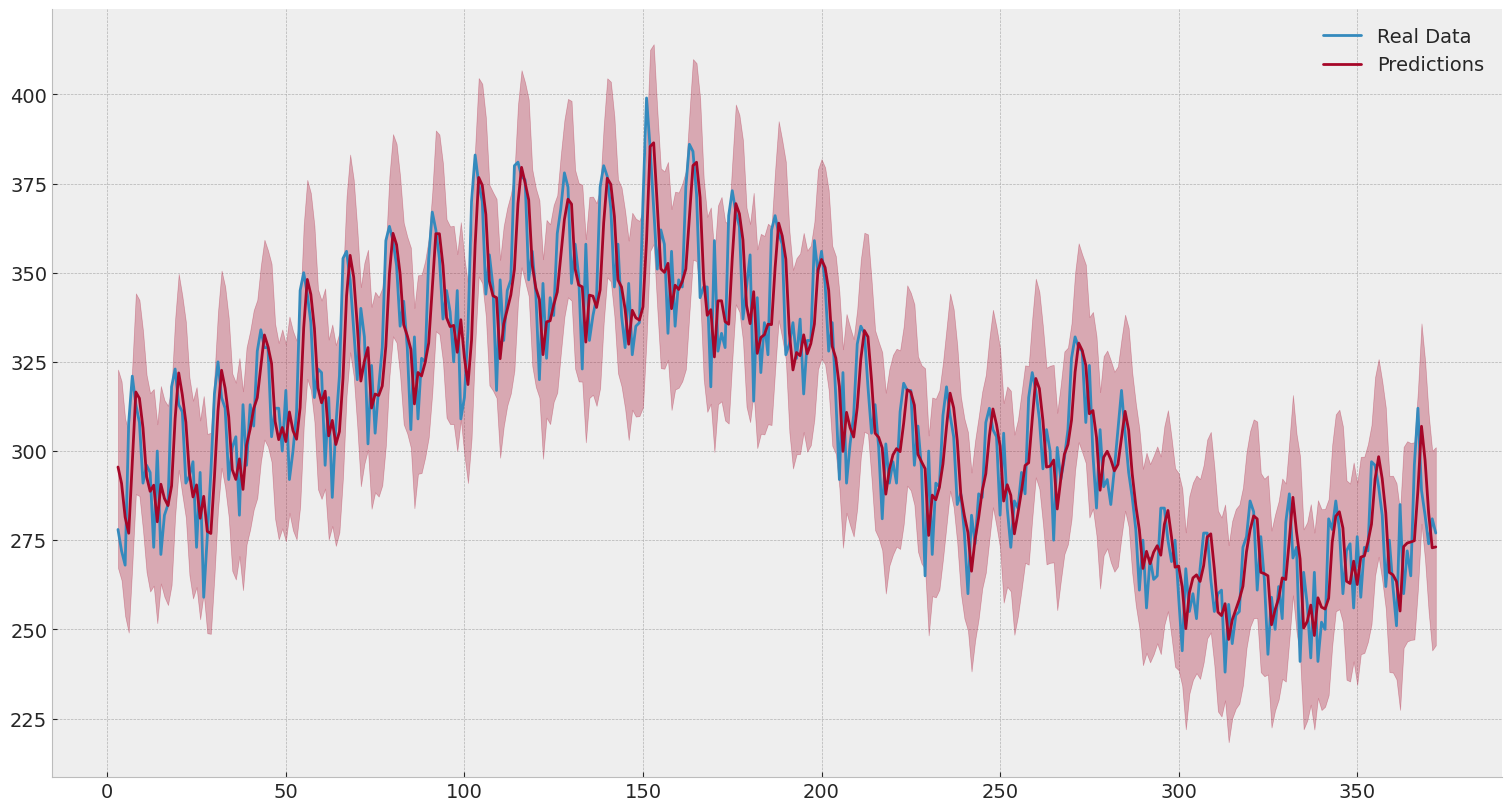

In [22]:
# Define highest density interval (HDI)
hdi_prob = 0.95

# Get predictions -> dims: chain, draw, time_idx
pred_full = idata_ts.predictions["y_pred"]
# Average per chain and draws -> dims: time_idx
ts_mean = pred_full.mean(dim=("chain", "draw")).values
# Compute the highest density interval (HDI) given a probability.
# The HDI is the shortest interval that contains the specified probability mass.
hdi_full = az.hdi(data=pred_full, prob=hdi_prob)
ts_lower = hdi_full.sel(ci_bound="lower").values
ts_upper = hdi_full.sel(ci_bound="upper").values


with plt.style.context("bmh"):
    # Plot
    fig, ax = plt.subplots(figsize=(15, 8))
    # Plot real values
    sns.lineplot(
        x=df_ts_bayes_pred[T_idx].values,
        y=df_ts_bayes_pred[Y].values,
        label="Real Data"
    )
    # Plot predictions and their intervals
    forescast_ax = sns.lineplot(
        x=df_ts_bayes_pred[T_idx].values,
        y=ts_mean,
        label="Predictions"
    )
    ax.fill_between(
        df_ts_bayes_pred[T_idx].values, ts_lower, ts_upper,
        color=forescast_ax.get_lines()[1].get_color(),
        alpha=0.3, label=f"{int(hdi_prob*100)}% HDI"
    )
    # Set legend and axis
    ax1.legend()
    plt.show()